# Experiment 7: Dimensionality Reduction and Model Evaluation (With and Without PCA)

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset -- a well-known UCI dataset, bundled
directly with scikit-learn (`sklearn.datasets.load_breast_cancer`), so it runs anywhere with no
external download required.
- Samples: 569
- Features: 30 numeric features computed from digitized images of a breast mass
  (radius, texture, perimeter, area, smoothness, etc.)
- Target classes: 2 -- malignant (212 samples) and benign (357 samples)
- Missing values: none


## Cell 1: Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              precision_recall_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")


Libraries imported successfully.


## Cell 2: Dataset Loading and Exploratory Data Analysis (EDA)

We load the dataset, check its shape, data types, missing values, and class distribution.

Dataset shape: (569, 30)

Data types:
 float64    30
Name: count, dtype: int64

Missing values: 0

Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64


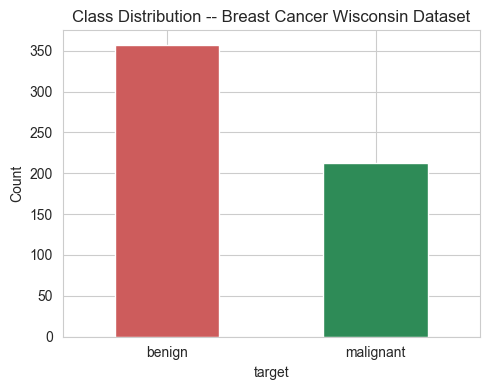

,mean radius,mean texture,mean smoothness,mean concavity
count,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,0.096360,0.088799
std,3.524049,4.301036,0.014064,0.079720
min,6.981000,9.710000,0.052630,0.000000
25%,11.700000,16.170000,0.086370,0.029560
50%,13.370000,18.840000,0.095870,0.061540
75%,15.780000,21.800000,0.105300,0.130700
max,28.110000,39.280000,0.163400,0.426800


In [3]:
# ---- Load the dataset ----
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign
class_names = {0: "malignant", 1: "benign"}

print("Dataset shape:", X.shape)
print("\nData types:\n", X.dtypes.value_counts())
print("\nMissing values:", int(X.isnull().sum().sum()))
print("\nClass distribution:")
print(y.map(class_names).value_counts())

# ---- Class distribution plot ----
plt.figure(figsize=(5, 4))
y.map(class_names).value_counts().plot(kind="bar", color=["indianred", "seagreen"])
plt.title("Class Distribution -- Breast Cancer Wisconsin Dataset")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- Quick summary statistics of a few key features ----
X[["mean radius", "mean texture", "mean smoothness", "mean concavity"]].describe()


## Cell 3: Preprocessing and PCA Analysis

Features are standardized (zero mean, unit variance) before PCA, since PCA is sensitive to
feature scale. We then fit PCA on the full standardized dataset purely to **choose** how many
components to keep (a 95% cumulative-explained-variance target) and to visualize the result
with a scree plot. The actual PCA used during model evaluation is fitted **inside** each
cross-validation fold (see Cell 4), so there is no data leakage from test folds into the PCA
transformation.

Components needed for >=95% variance: 10
Actual cumulative variance at that point: 95.16%
Dimensionality reduction: 30 -> 10 features (66.7% reduction)


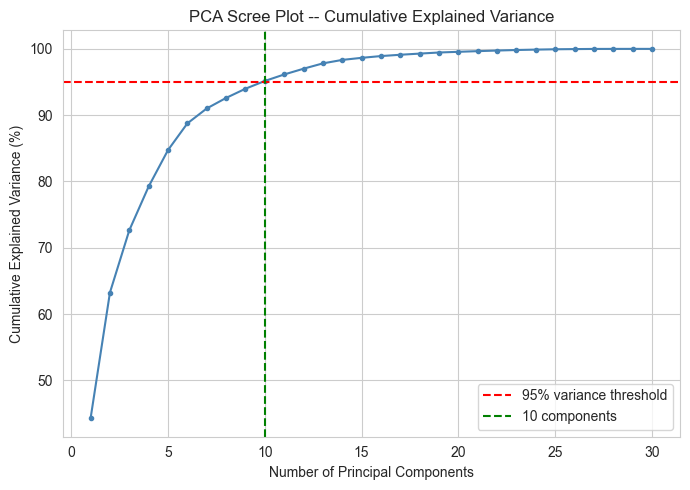

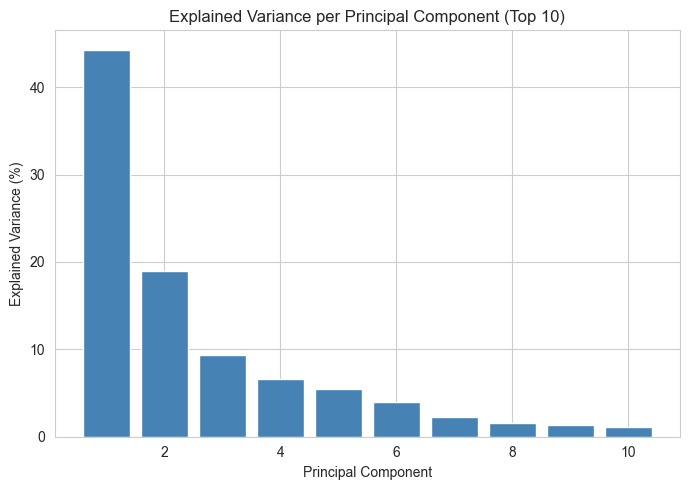

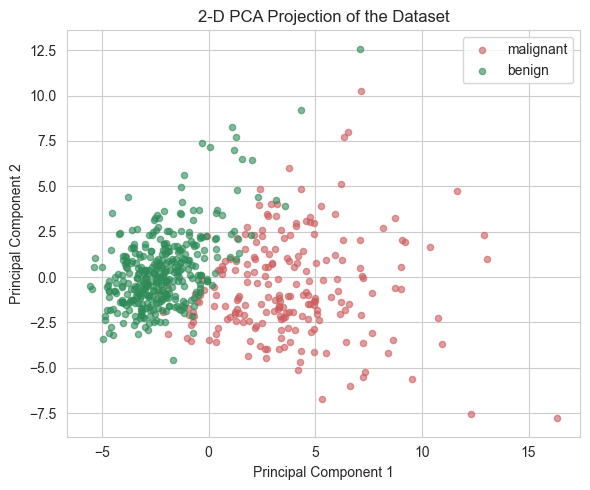

In [4]:
# ---- Standardize the full dataset (for PCA design/visualization only) ----
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# ---- Fit PCA with all components to study the variance curve ----
pca_full = PCA().fit(X_scaled_full)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Choose the smallest number of components that explains >= 95% variance.
n_components_95 = int(np.argmax(cum_var >= 0.95) + 1)
variance_at_95 = cum_var[n_components_95 - 1] * 100
print(f"Components needed for >=95% variance: {n_components_95}")
print(f"Actual cumulative variance at that point: {variance_at_95:.2f}%")
print(f"Dimensionality reduction: {X.shape[1]} -> {n_components_95} features "
      f"({(1 - n_components_95 / X.shape[1]) * 100:.1f}% reduction)")

# ---- Scree plot: cumulative explained variance ----
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var * 100, marker="o", markersize=3, color="steelblue")
plt.axhline(95, color="red", linestyle="--", label="95% variance threshold")
plt.axvline(n_components_95, color="green", linestyle="--", label=f"{n_components_95} components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Scree Plot -- Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Per-component variance (top 10) ----
plt.figure(figsize=(7, 5))
plt.bar(range(1, 11), pca_full.explained_variance_ratio_[:10] * 100, color="steelblue")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance per Principal Component (Top 10)")
plt.tight_layout()
plt.show()

# ---- 2-D PCA projection, purely for visualizing class separability ----
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled_full)
plt.figure(figsize=(6, 5))
for label, name, color in [(0, "malignant", "indianred"), (1, "benign", "seagreen")]:
    mask = y == label
    plt.scatter(pca_2d[mask, 0], pca_2d[mask, 1], label=name, alpha=0.6, color=color, s=20)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2-D PCA Projection of the Dataset")
plt.legend()
plt.tight_layout()
plt.show()

# NOTE: This PCA fit (on the full dataset) is only used to CHOOSE n_components=0.95
# and to visualize the effect of PCA. The actual PCA used for model training/evaluation
# below is fitted fresh inside every cross-validation fold via a Pipeline, so no
# information from a validation fold ever leaks into the PCA transformation.


## Cell 4: Model Definitions and Hyperparameter Grids

Every model is wrapped in a `Pipeline` (`StandardScaler` -> optional `PCA(n_components=0.95)`
-> classifier), so that scaling and PCA are refit on the training fold only, inside every
cross-validation split -- this avoids information leaking from the validation fold into the
preprocessing step. `GridSearchCV` with `cv=5` (stratified) is used for hyperparameter tuning,
scoring both accuracy and weighted F1, and the fold-by-fold scores of the *best* hyperparameter
combination are extracted directly from `cv_results_`.

In [5]:
def build_pipeline(estimator, use_pca):
    """Wrap any estimator in Scaler -> (optional PCA) -> Model, so that
    preprocessing is refit inside every CV fold (no data leakage)."""
    steps = [("scaler", StandardScaler())]
    if use_pca:
        steps.append(("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)))
    steps.append(("model", estimator))
    return Pipeline(steps)


# Each entry: model name -> (estimator, hyperparameter grid).
# Grid keys are prefixed "model__" because the estimator sits inside a Pipeline
# named "model".
model_specs = {
    "SVM": (
        SVC(probability=True, random_state=RANDOM_STATE),
        [
            {"model__kernel": ["linear"], "model__C": [0.1, 1, 10]},
            {"model__kernel": ["rbf"], "model__C": [0.1, 1, 10],
             "model__gamma": ["scale", 0.01, 0.1]},
        ],
    ),
    "Naive Bayes": (
        GaussianNB(),
        {"model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]},
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"model__n_neighbors": [3, 5, 7, 9],
         "model__weights": ["uniform", "distance"],
         "model__metric": ["euclidean", "manhattan"]},
    ),
    "Logistic Regression": (
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        {"model__C": [0.01, 0.1, 1, 10], "model__penalty": ["l2"]},
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"model__max_depth": [3, 5, 10, None],
         "model__min_samples_split": [2, 5, 10]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"model__n_estimators": [100, 200],
         "model__max_depth": [5, 10, None]},
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {"model__n_estimators": [50, 100, 200],
         "model__learning_rate": [0.01, 0.1, 1.0]},
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"model__n_estimators": [100, 200],
         "model__learning_rate": [0.01, 0.1],
         "model__max_depth": [2, 3]},
    ),
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
        {"model__n_estimators": [100, 200],
         "model__learning_rate": [0.01, 0.1],
         "model__max_depth": [3, 5]},
    ),
}

STACKING_NAME = "Stacking"


def build_stacking(use_pca):
    """Stacking ensemble: Logistic Regression + Random Forest + KNN as base
    learners, with a Logistic Regression meta-learner on top."""
    base_learners = [
        ("lr", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
        ("knn", KNeighborsClassifier(n_neighbors=5)),
    ]
    stack = StackingClassifier(
        estimators=base_learners,
        final_estimator=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        cv=5, n_jobs=-1,
    )
    return build_pipeline(stack, use_pca)


cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Defined {len(model_specs)} tunable models plus 1 Stacking ensemble.")
print("5-fold Stratified CV will be used throughout, matching the class ratio in every fold.")


Defined 9 tunable models plus 1 Stacking ensemble.
5-fold Stratified CV will be used throughout, matching the class ratio in every fold.


## Cell 5: Train and Evaluate Every Model (No-PCA vs With-PCA)

This cell runs `GridSearchCV` for every model in both settings, and a plain 5-fold
`cross_validate` for the Stacking ensemble (which has a fixed architecture rather than a
hyperparameter grid), then assembles the full results table.

In [6]:
def run_grid_search(estimator, param_grid, use_pca):
    """Run GridSearchCV (5-fold) for one model in one setting (No-PCA / With-PCA)
    and pull out the fold-by-fold accuracy/F1 for the BEST hyperparameter combo."""
    pipe = build_pipeline(estimator, use_pca)
    grid = GridSearchCV(
        pipe, param_grid, cv=cv_splitter,
        scoring={"accuracy": "accuracy", "f1": "f1_weighted"},
        refit="accuracy", n_jobs=-1,
    )
    grid.fit(X, y)
    best_idx = grid.best_index_
    fold_acc = [grid.cv_results_[f"split{i}_test_accuracy"][best_idx] for i in range(5)]
    fold_f1 = [grid.cv_results_[f"split{i}_test_f1"][best_idx] for i in range(5)]
    return {
        "best_params": grid.best_params_,
        "fold_accuracy": fold_acc,
        "fold_f1": fold_f1,
        "avg_accuracy": float(np.mean(fold_acc)),
        "std_accuracy": float(np.std(fold_acc)),
        "avg_f1": float(np.mean(fold_f1)),
        "std_f1": float(np.std(fold_f1)),
        "estimator": grid.best_estimator_,
    }


def run_cv_only(pipe):
    """Plain 5-fold cross-validation, used for Stacking (fixed architecture,
    no hyperparameter grid required by the assignment)."""
    scoring = {"accuracy": "accuracy", "f1": "f1_weighted"}
    cvres = cross_validate(pipe, X, y, cv=cv_splitter, scoring=scoring, n_jobs=-1)
    fold_acc, fold_f1 = list(cvres["test_accuracy"]), list(cvres["test_f1"])
    fitted = pipe.fit(X, y)  # final fit on all data, for confusion matrix / ROC plots
    return {
        "best_params": "N/A (fixed architecture: LR + RF + KNN -> meta LR)",
        "fold_accuracy": fold_acc, "fold_f1": fold_f1,
        "avg_accuracy": float(np.mean(fold_acc)), "std_accuracy": float(np.std(fold_acc)),
        "avg_f1": float(np.mean(fold_f1)), "std_f1": float(np.std(fold_f1)),
    }, fitted


results = {}
best_estimators = {}

print("=" * 72)
print("RUNNING GRID SEARCH + 5-FOLD CV FOR EACH MODEL (NO-PCA vs WITH-PCA)")
print("=" * 72)

for name, (estimator, grid_params) in model_specs.items():
    t0 = time.time()
    no_pca_res = run_grid_search(estimator, grid_params, use_pca=False)
    with_pca_res = run_grid_search(estimator, grid_params, use_pca=True)
    best_estimators[(name, "no_pca")] = no_pca_res.pop("estimator")
    best_estimators[(name, "with_pca")] = with_pca_res.pop("estimator")
    results[name] = {"no_pca": no_pca_res, "with_pca": with_pca_res}
    print(f"\n--- {name} ({time.time()-t0:.1f}s) ---")
    print(f"  No-PCA  : acc={no_pca_res['avg_accuracy']:.4f}  f1={no_pca_res['avg_f1']:.4f}  best={no_pca_res['best_params']}")
    print(f"  With-PCA: acc={with_pca_res['avg_accuracy']:.4f}  f1={with_pca_res['avg_f1']:.4f}  best={with_pca_res['best_params']}")

# ---- Stacking ensemble (no hyperparameter grid) ----
print(f"\n--- {STACKING_NAME} ---")
stack_no_pca_res, stack_no_pca_fitted = run_cv_only(build_stacking(False))
stack_with_pca_res, stack_with_pca_fitted = run_cv_only(build_stacking(True))
results[STACKING_NAME] = {"no_pca": stack_no_pca_res, "with_pca": stack_with_pca_res}
best_estimators[(STACKING_NAME, "no_pca")] = stack_no_pca_fitted
best_estimators[(STACKING_NAME, "with_pca")] = stack_with_pca_fitted
print(f"  No-PCA  : acc={stack_no_pca_res['avg_accuracy']:.4f}  f1={stack_no_pca_res['avg_f1']:.4f}")
print(f"  With-PCA: acc={stack_with_pca_res['avg_accuracy']:.4f}  f1={stack_with_pca_res['avg_f1']:.4f}")

print("\nAll models trained and evaluated.")


RUNNING GRID SEARCH + 5-FOLD CV FOR EACH MODEL (NO-PCA vs WITH-PCA)

--- SVM (4.9s) ---
  No-PCA  : acc=0.9807  f1=0.9806  best={'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
  With-PCA: acc=0.9754  f1=0.9753  best={'model__C': 1, 'model__kernel': 'linear'}

--- Naive Bayes (0.1s) ---
  No-PCA  : acc=0.9297  f1=0.9295  best={'model__var_smoothing': 1e-09}
  With-PCA: acc=0.9174  f1=0.9167  best={'model__var_smoothing': 1e-09}

--- KNN (0.5s) ---
  No-PCA  : acc=0.9684  f1=0.9681  best={'model__metric': 'euclidean', 'model__n_neighbors': 9, 'model__weights': 'distance'}
  With-PCA: acc=0.9649  f1=0.9645  best={'model__metric': 'manhattan', 'model__n_neighbors': 9, 'model__weights': 'uniform'}

--- Logistic Regression (0.1s) ---
  No-PCA  : acc=0.9737  f1=0.9734  best={'model__C': 0.1, 'model__penalty': 'l2'}
  With-PCA: acc=0.9772  f1=0.9771  best={'model__C': 1, 'model__penalty': 'l2'}

--- Decision Tree (0.2s) ---
  No-PCA  : acc=0.9280  f1=0.9271  best={'model__max_de

## Cell 6: Results Table (5-Fold CV, No-PCA vs With-PCA)

In [7]:
rows = []
for name, r in results.items():
    row = {"Model": name}
    for i in range(5):
        row[f"Fold{i+1}_NoPCA_Acc"] = r["no_pca"]["fold_accuracy"][i]
        row[f"Fold{i+1}_WithPCA_Acc"] = r["with_pca"]["fold_accuracy"][i]
    row["Avg_Acc_NoPCA"] = r["no_pca"]["avg_accuracy"]
    row["Avg_Acc_WithPCA"] = r["with_pca"]["avg_accuracy"]
    row["Std_Acc_NoPCA"] = r["no_pca"]["std_accuracy"]
    row["Std_Acc_WithPCA"] = r["with_pca"]["std_accuracy"]
    row["Avg_F1_NoPCA"] = r["no_pca"]["avg_f1"]
    row["Avg_F1_WithPCA"] = r["with_pca"]["avg_f1"]
    row["BestParams_NoPCA"] = str(r["no_pca"]["best_params"])
    row["BestParams_WithPCA"] = str(r["with_pca"]["best_params"])
    rows.append(row)

results_df = pd.DataFrame(rows)
results_df.to_csv("experiment7_results_table.csv", index=False)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
print("Fold-wise accuracy (No-PCA):")
display(results_df[["Model"] + [f"Fold{i+1}_NoPCA_Acc" for i in range(5)] +
                    ["Avg_Acc_NoPCA", "Std_Acc_NoPCA"]].round(4))

print("\nFold-wise accuracy (With-PCA):")
display(results_df[["Model"] + [f"Fold{i+1}_WithPCA_Acc" for i in range(5)] +
                    ["Avg_Acc_WithPCA", "Std_Acc_WithPCA"]].round(4))

print("\nAverage Accuracy & F1 -- No-PCA vs With-PCA:")
display(results_df[["Model", "Avg_Acc_NoPCA", "Avg_Acc_WithPCA",
                     "Avg_F1_NoPCA", "Avg_F1_WithPCA"]].round(4))

print("\nBest hyperparameters found per model:")
display(results_df[["Model", "BestParams_NoPCA", "BestParams_WithPCA"]])


Fold-wise accuracy (No-PCA):


,Model,Fold1_NoPCA_Acc,Fold2_NoPCA_Acc,Fold3_NoPCA_Acc,Fold4_NoPCA_Acc,Fold5_NoPCA_Acc,Avg_Acc_NoPCA,Std_Acc_NoPCA
0,SVM,1.0000,0.9474,0.9825,0.9912,0.9823,0.9807,0.0179
1,Naive Bayes,0.9561,0.9123,0.9298,0.9035,0.9469,0.9297,0.0199
2,KNN,0.9825,0.9561,0.9474,0.9825,0.9735,0.9684,0.0142
3,Logistic Regression,0.9737,0.9474,0.9649,0.9912,0.9912,0.9737,0.0166
4,Decision Tree,0.9386,0.8860,0.9298,0.9298,0.9558,0.9280,0.0230
5,Random Forest,0.9649,0.9386,0.9561,0.9474,0.9735,0.9561,0.0123
6,AdaBoost,0.9912,0.9386,0.9561,0.9737,0.9735,0.9666,0.0179
7,Gradient Boosting,0.9737,0.9123,0.9561,0.9649,0.9823,0.9579,0.0244
8,XGBoost,0.9825,0.9386,0.9649,0.9737,0.9735,0.9666,0.0151
9,Stacking,0.9825,0.9649,0.9737,0.9649,0.9823,0.9737,0.0078



Fold-wise accuracy (With-PCA):


,Model,Fold1_WithPCA_Acc,Fold2_WithPCA_Acc,Fold3_WithPCA_Acc,Fold4_WithPCA_Acc,Fold5_WithPCA_Acc,Avg_Acc_WithPCA,Std_Acc_WithPCA
0,SVM,0.9825,0.9737,0.9649,0.9737,0.9823,0.9754,0.0065
1,Naive Bayes,0.9737,0.9123,0.9035,0.8860,0.9115,0.9174,0.0297
2,KNN,0.9912,0.9474,0.9474,0.9649,0.9735,0.9649,0.0166
3,Logistic Regression,0.9737,0.9737,0.9737,0.9737,0.9912,0.9772,0.0070
4,Decision Tree,0.9649,0.9386,0.9211,0.8947,0.9646,0.9368,0.0268
5,Random Forest,0.9825,0.9386,0.9474,0.9123,0.9735,0.9508,0.0251
6,AdaBoost,0.9737,0.9211,0.9561,0.9561,0.9912,0.9596,0.0233
7,Gradient Boosting,0.9737,0.9474,0.9474,0.9211,0.9735,0.9526,0.0196
8,XGBoost,0.9912,0.9561,0.9386,0.9474,0.9823,0.9631,0.0203
9,Stacking,0.9825,0.9737,0.9737,0.9649,0.9823,0.9754,0.0065



Average Accuracy & F1 -- No-PCA vs With-PCA:


,Model,Avg_Acc_NoPCA,Avg_Acc_WithPCA,Avg_F1_NoPCA,Avg_F1_WithPCA
0,SVM,0.9807,0.9754,0.9806,0.9753
1,Naive Bayes,0.9297,0.9174,0.9295,0.9167
2,KNN,0.9684,0.9649,0.9681,0.9645
3,Logistic Regression,0.9737,0.9772,0.9734,0.9771
4,Decision Tree,0.9280,0.9368,0.9271,0.9369
5,Random Forest,0.9561,0.9508,0.9560,0.9507
6,AdaBoost,0.9666,0.9596,0.9664,0.9594
7,Gradient Boosting,0.9579,0.9526,0.9575,0.9525
8,XGBoost,0.9666,0.9631,0.9664,0.9629
9,Stacking,0.9737,0.9754,0.9736,0.9754



Best hyperparameters found per model:


,Model,BestParams_NoPCA,BestParams_WithPCA
0,SVM,"{'model__C': 10, 'model__gamma': 0.01, 'model_...","{'model__C': 1, 'model__kernel': 'linear'}"
1,Naive Bayes,{'model__var_smoothing': 1e-09},{'model__var_smoothing': 1e-09}
2,KNN,"{'model__metric': 'euclidean', 'model__n_neigh...","{'model__metric': 'manhattan', 'model__n_neigh..."
3,Logistic Regression,"{'model__C': 0.1, 'model__penalty': 'l2'}","{'model__C': 1, 'model__penalty': 'l2'}"
4,Decision Tree,"{'model__max_depth': 5, 'model__min_samples_sp...","{'model__max_depth': 3, 'model__min_samples_sp..."
5,Random Forest,"{'model__max_depth': 10, 'model__n_estimators'...","{'model__max_depth': 10, 'model__n_estimators'..."
6,AdaBoost,"{'model__learning_rate': 1.0, 'model__n_estima...","{'model__learning_rate': 1.0, 'model__n_estima..."
7,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...","{'model__learning_rate': 0.1, 'model__max_dept..."
8,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...","{'model__learning_rate': 0.1, 'model__max_dept..."
9,Stacking,N/A (fixed architecture: LR + RF + KNN -> meta...,N/A (fixed architecture: LR + RF + KNN -> meta...


## Cell 7: Comparison Visualizations

Accuracy comparison, fold-to-fold stability comparison, confusion matrices, ROC curves, and
Precision-Recall curves for a few representative models.

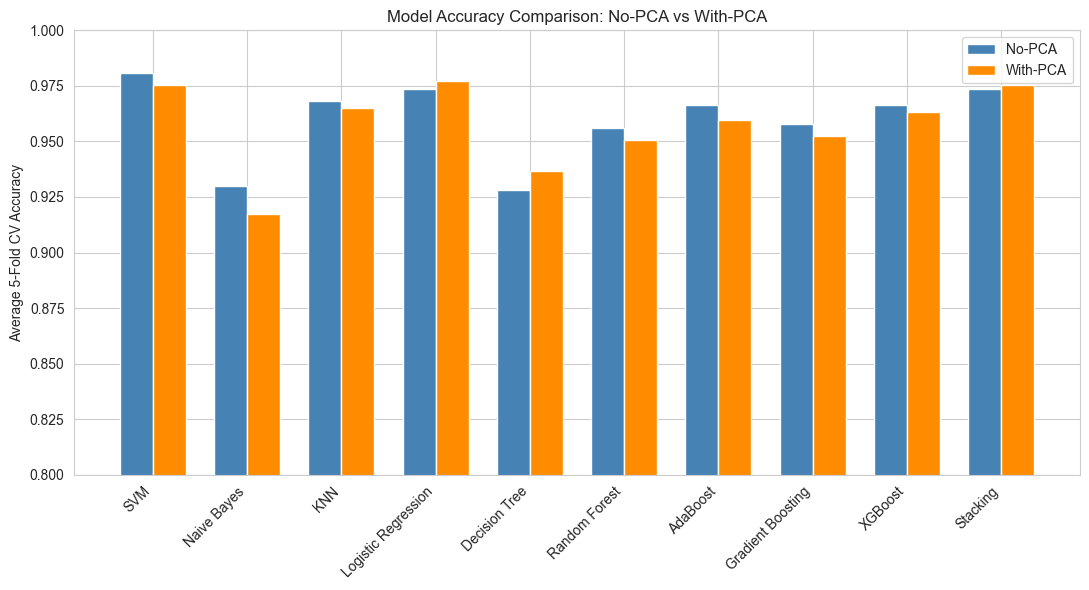

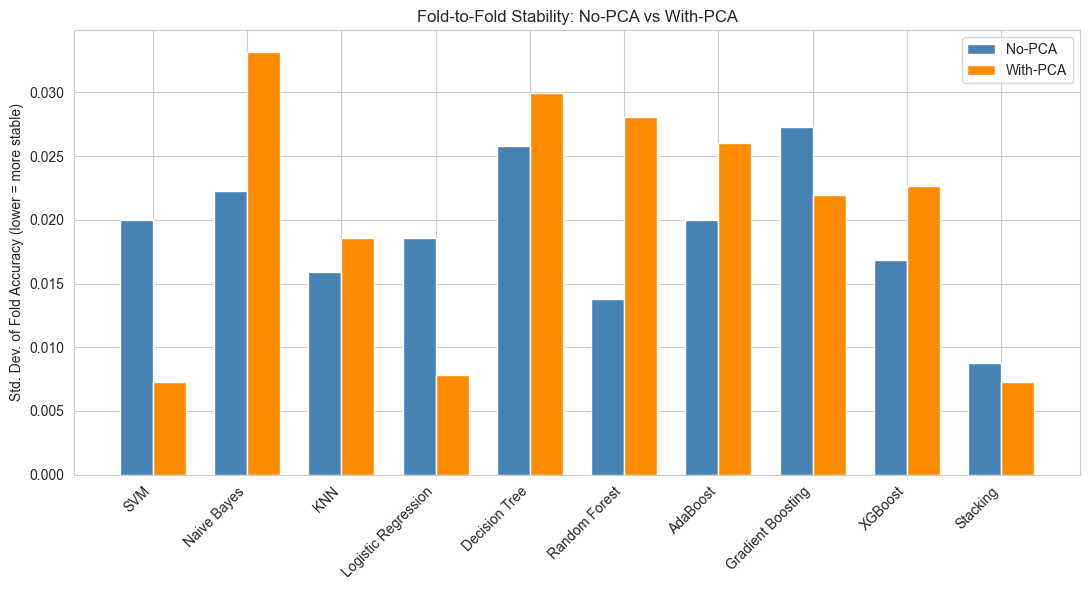

Selected models for detailed visualization: ['Logistic Regression', 'SVM', 'Random Forest'] (best overall With-PCA model: Logistic Regression)


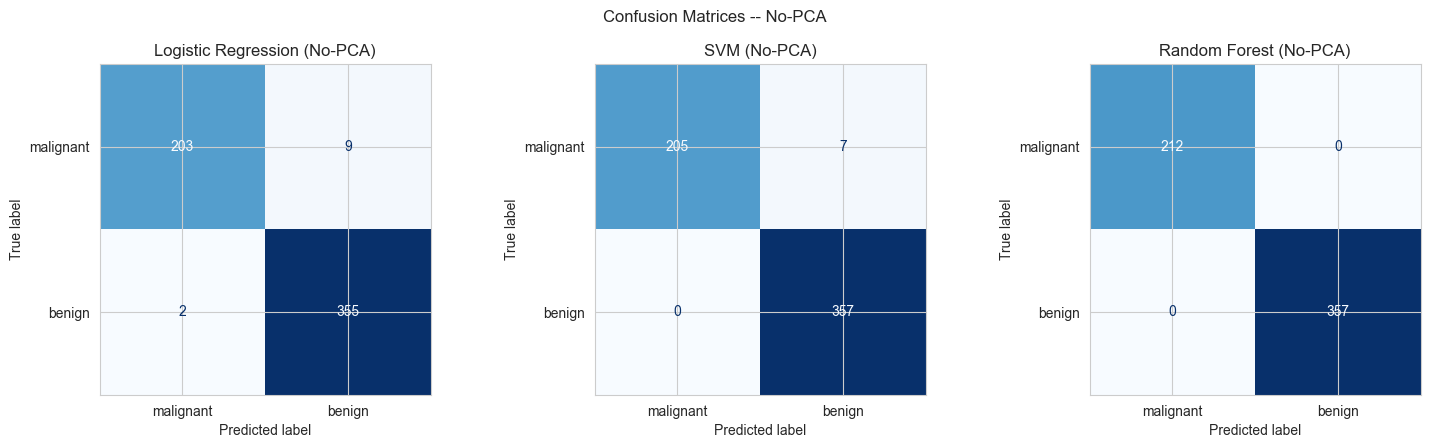

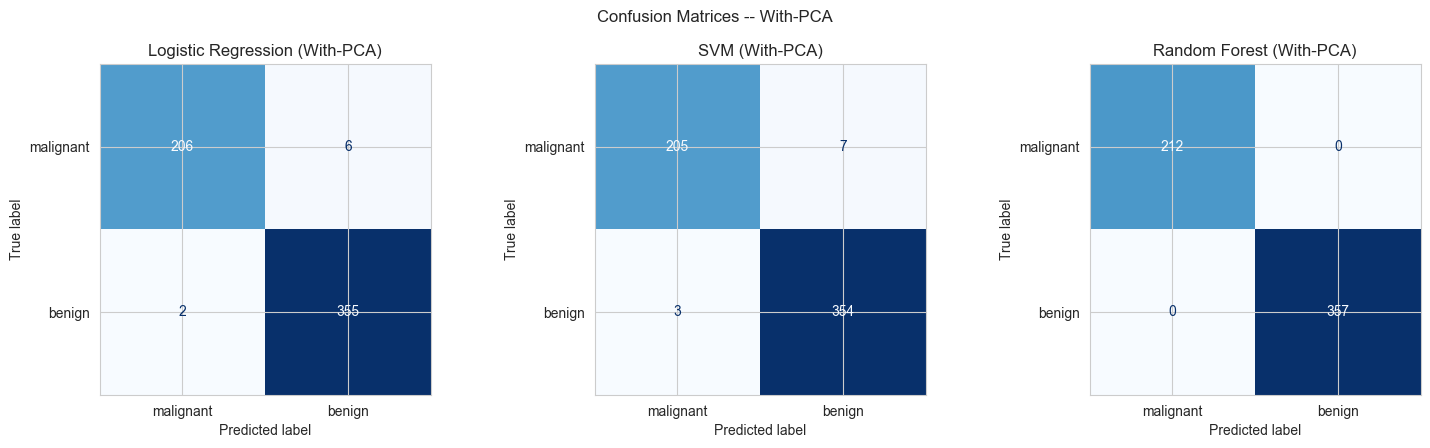

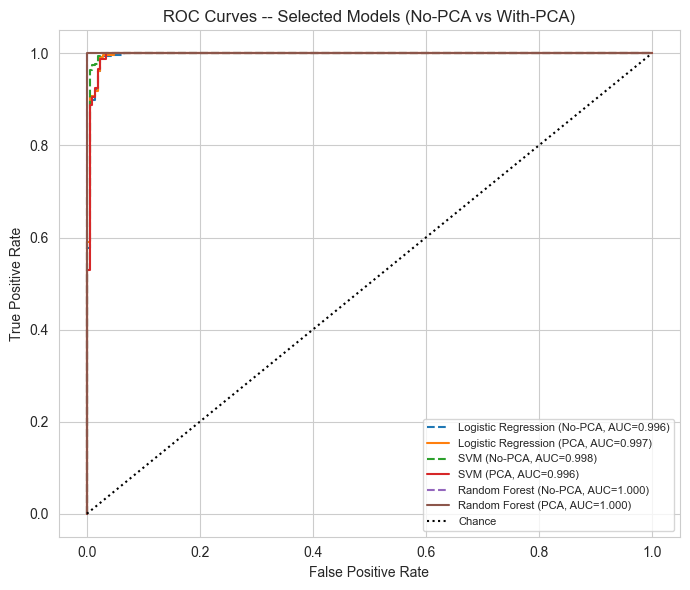

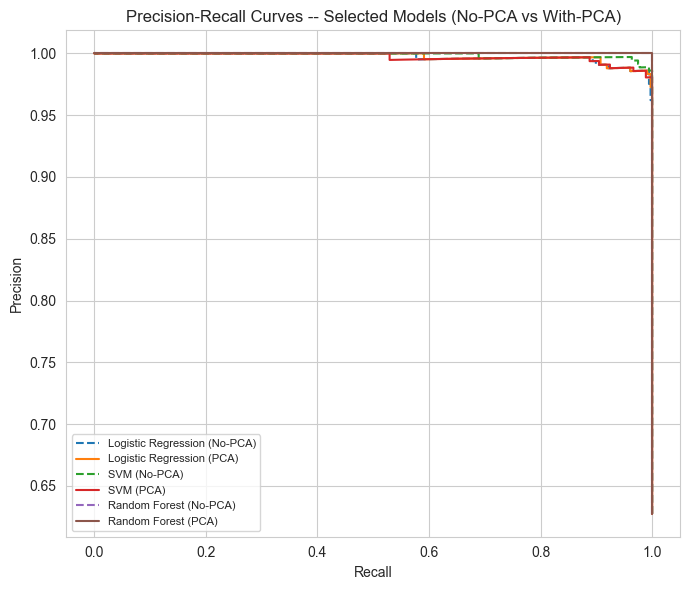

In [8]:
# ---- Accuracy comparison bar chart ----
x_pos = np.arange(len(results_df))
width = 0.35
plt.figure(figsize=(11, 6))
plt.bar(x_pos - width/2, results_df["Avg_Acc_NoPCA"], width, label="No-PCA", color="steelblue")
plt.bar(x_pos + width/2, results_df["Avg_Acc_WithPCA"], width, label="With-PCA", color="darkorange")
plt.xticks(x_pos, results_df["Model"], rotation=45, ha="right")
plt.ylabel("Average 5-Fold CV Accuracy")
plt.title("Model Accuracy Comparison: No-PCA vs With-PCA")
plt.ylim(0.8, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Fold-to-fold stability comparison (std. dev. of fold accuracy) ----
fold_cols_no = [f"Fold{i+1}_NoPCA_Acc" for i in range(5)]
fold_cols_with = [f"Fold{i+1}_WithPCA_Acc" for i in range(5)]
stability_no = results_df.set_index("Model")[fold_cols_no].std(axis=1)
stability_with = results_df.set_index("Model")[fold_cols_with].std(axis=1)

plt.figure(figsize=(11, 6))
plt.bar(x_pos - width/2, stability_no.values, width, label="No-PCA", color="steelblue")
plt.bar(x_pos + width/2, stability_with.values, width, label="With-PCA", color="darkorange")
plt.xticks(x_pos, results_df["Model"], rotation=45, ha="right")
plt.ylabel("Std. Dev. of Fold Accuracy (lower = more stable)")
plt.title("Fold-to-Fold Stability: No-PCA vs With-PCA")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Confusion matrices + ROC/PR curves for selected models ----
best_model_name = results_df.loc[results_df["Avg_Acc_WithPCA"].idxmax(), "Model"]
selected_models = list(dict.fromkeys([best_model_name, "SVM", "Random Forest"]))
print("Selected models for detailed visualization:", selected_models,
      f"(best overall With-PCA model: {best_model_name})")

for setting in ["no_pca", "with_pca"]:
    fig, axes = plt.subplots(1, len(selected_models), figsize=(5 * len(selected_models), 4.5))
    if len(selected_models) == 1:
        axes = [axes]
    for ax, mname in zip(axes, selected_models):
        est = best_estimators[(mname, setting)]
        y_pred = est.predict(X)
        cm = confusion_matrix(y, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant", "benign"])
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{mname} ({'With-PCA' if setting == 'with_pca' else 'No-PCA'})")
    plt.suptitle(f"Confusion Matrices -- {'With-PCA' if setting=='with_pca' else 'No-PCA'}")
    plt.tight_layout()
    plt.show()

# ---- ROC curves ----
plt.figure(figsize=(7, 6))
for mname in selected_models:
    for setting, style in [("no_pca", "--"), ("with_pca", "-")]:
        est = best_estimators[(mname, setting)]
        y_score = est.predict_proba(X)[:, 1] if hasattr(est, "predict_proba") else est.decision_function(X)
        fpr, tpr, _ = roc_curve(y, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, style, label=f"{mname} ({'PCA' if setting=='with_pca' else 'No-PCA'}, AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k:", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves -- Selected Models (No-PCA vs With-PCA)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ---- Precision-Recall curves ----
plt.figure(figsize=(7, 6))
for mname in selected_models:
    for setting, style in [("no_pca", "--"), ("with_pca", "-")]:
        est = best_estimators[(mname, setting)]
        y_score = est.predict_proba(X)[:, 1] if hasattr(est, "predict_proba") else est.decision_function(X)
        precision, recall, _ = precision_recall_curve(y, y_score)
        plt.plot(recall, precision, style, label=f"{mname} ({'PCA' if setting=='with_pca' else 'No-PCA'})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves -- Selected Models (No-PCA vs With-PCA)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Observations (auto-generated from the results above)

In [9]:
# This cell prints a short, automatically-generated summary of the observation
# questions from the assignment, computed directly from the results table above
# (not hand-written), so it always reflects the actual numbers obtained.

diff = results_df["Avg_Acc_WithPCA"] - results_df["Avg_Acc_NoPCA"]
improved = results_df.loc[diff > 0, "Model"].tolist()
worsened = results_df.loc[diff < 0, "Model"].tolist()
best_improvement_model = results_df.loc[diff.idxmax(), "Model"]
worst_change_model = results_df.loc[diff.idxmin(), "Model"]

stability_diff = stability_with - stability_no  # negative = PCA more stable
more_stable_with_pca = stability_diff[stability_diff < 0].index.tolist()
less_stable_with_pca = stability_diff[stability_diff > 0].index.tolist()

print("Models whose average accuracy IMPROVED with PCA:", improved)
print("Models whose average accuracy DECREASED with PCA:", worsened)
print(f"\nLargest improvement from PCA: {best_improvement_model} "
      f"({diff[results_df['Model'] == best_improvement_model].values[0]*100:+.2f} pp)")
print(f"Largest drop from PCA: {worst_change_model} "
      f"({diff[results_df['Model'] == worst_change_model].values[0]*100:+.2f} pp)")

print("\nModels that became MORE stable (lower fold-to-fold std) with PCA:", more_stable_with_pca)
print("Models that became LESS stable with PCA:", less_stable_with_pca)

print(f"\nBest overall model (With-PCA setting, by average accuracy): {best_model_name}")
print(f"PCA reduced dimensionality from {X.shape[1]} to {n_components_95} features "
      f"({(1 - n_components_95 / X.shape[1]) * 100:.1f}% reduction) while retaining "
      f"{variance_at_95:.2f}% of the variance.")


Models whose average accuracy IMPROVED with PCA: ['Logistic Regression', 'Decision Tree', 'Stacking']
Models whose average accuracy DECREASED with PCA: ['SVM', 'Naive Bayes', 'KNN', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost']

Largest improvement from PCA: Decision Tree (+0.88 pp)
Largest drop from PCA: Naive Bayes (-1.23 pp)

Models that became MORE stable (lower fold-to-fold std) with PCA: ['SVM', 'Logistic Regression', 'Gradient Boosting', 'Stacking']
Models that became LESS stable with PCA: ['Naive Bayes', 'KNN', 'Decision Tree', 'Random Forest', 'AdaBoost', 'XGBoost']

Best overall model (With-PCA setting, by average accuracy): Logistic Regression
PCA reduced dimensionality from 30 to 10 features (66.7% reduction) while retaining 95.16% of the variance.
